# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, get_top_indices, create_top_sequences, visualize_top_sequences
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence import SequencePreprocessor, PreprocessingMode
from src.ml.xthreat import get_default_xt_model


In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Load Trained Model

In [4]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'
model = load_model(MODEL_TYPE)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [5]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 6, 46)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │       179,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_weights               │ [(None, 128), (None,   │           134 │
│ (AttentionLayer)                │ 6)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ value (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,154,327 (4.40 MB)

 Trainable params: 384,775 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 769,552 (2.94 MB)

## 3. Preprocess Data for Analysis

In [6]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=PreprocessingMode.TRAINING)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: training)
 → Generated 1301 sequences, 1301 labels for match 3943043
Validation set preprocessed: 1301 sequences


In [7]:
X.shape

(1301, 6, 46)

In [8]:
p.shape

(1301,)

In [9]:
p[0:2]

array([   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
       0  3943043  152820f0-6ca9-4df3-943b-a67d568ff472          1         0.340      768    99174.0  52.45625  34.0425   22.18125  35.0625        0          1            5          0   England    Kobbie Mainoo           2      Pass  2.529454           False         False  0.0                 768              England  0.010165 -30.2750   1.020  30.292178  3.107914      0.000                0
       1  3943043  9c107df3-a3c8-4ad5-bc35-00214087a105          1         2.870      768     3468.0  22.18125  35.0625   25.06875  41.1825       21          1            0          1   England  Jordan Pickford

## 4. Analysis


#### Make predictions on match sequences

In [10]:
predictions = model.predict(X, batch_size=32, verbose=0)
predictions

{'value': array([[0.0315219 ],
        [0.0115834 ],
        [0.01275667],
        ...,
        [0.02559845],
        [0.01353634],
        [0.02144041]], dtype=float32),
 'attention_weights': array([[0.10421646, 0.10090752, 0.11229526, 0.14540061, 0.28654978,
         0.2506304 ],
        [0.12989563, 0.12473743, 0.12696967, 0.1572784 , 0.2202027 ,
         0.24091615],
        [0.13065737, 0.12030376, 0.13184421, 0.14595012, 0.24572293,
         0.22552167],
        ...,
        [0.11412593, 0.11551161, 0.11211744, 0.16079739, 0.27397496,
         0.22347265],
        [0.13212648, 0.126513  , 0.13589081, 0.17294712, 0.24635495,
         0.18616766],
        [0.14148898, 0.13117516, 0.13449678, 0.15007776, 0.22580288,
         0.21695837]], dtype=float32)}

#### Predictions

In [11]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 1301
Sum of all predicted values: 37.924
Has attention weights: True


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [12]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, None, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Possession id =       game_id                     original_event_id  period_id  time_seconds  team_id  player_id    start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name          player_name  possession    type_name  duration  under_pressure  counterpress        xG  possession_team_id possession_team_name        xT      dx      dy   distance     angle  time_diff  opposite_action
1855  3943043  5423b3d4-6ae5-4e45-ac1b-461d6085c42f          2      2652.691      768    39461.0  104.95625  67.9575   95.76875  30.5575        5          1            4       1855   England          Cole Palmer         138         Pass  1.949813           False         False  0.000000                 768              England  0.037926 -9.1875 -37.400  38.511948 -1.811681      0.000                0
1856  3943043  a7918f5b-489f-4e7d-b815-a9409488f7d0          2      2654.641      768     3943.0   95.76875  30.5575  103.7312

#### Top possessions information

In [13]:
sorted_indices = get_top_indices(predicted_values)
top_indices = sorted_indices[:50]
top_indices

array([1297,  845, 1290, 1148, 1013,   80,  651,  224, 1018,  223, 1147,
        555, 1005, 1268,   79, 1017, 1296,  301,   76,  216, 1080, 1012,
       1289,   77, 1194,  848,  652, 1193,  849, 1081,  362,  650,  711,
        846,  520,  847, 1056,  217, 1295,  375,  373,  710, 1195, 1146,
        690, 1294,  203, 1293,  253,  374])

#### Save top possessions dataframe

In [14]:
p[2]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
4,3943043,987a3f1e-4dc4-4833-8896-5513e35c3fc5,1,35.658,772,22128.0,7.91875,19.4225,7.74375,19.4225,21,1,0,4,Spain,Robin Aime Robert Le Normand,3,Carry,0.620663,False,False,0.0,772,Spain,0.008880,-0.1750,0.000,0.175000,3.141593,1.218,0
5,3943043,660f4d9e-9ae4-4a8c-9f44-acdbc0a04e8c,1,36.279,772,22128.0,7.74375,19.4225,17.98125,3.6125,0,1,5,5,Spain,Robin Aime Robert Le Normand,3,Pass,1.390837,False,False,0.0,772,Spain,0.008449,10.2375,-15.810,18.835140,-0.996157,0.621,0
6,3943043,786c039a-7010-475c-9a75-9bf41b4e5700,1,37.670,772,5721.0,17.98125,3.6125,24.98125,3.1025,21,1,0,6,Spain,Daniel Carvajal Ramos,3,Carry,1.766383,True,False,0.0,772,Spain,0.008449,7.0000,-0.510,7.018554,-0.072729,1.391,0
7,3943043,dd8cccdf-05dc-41ca-b617-8812c416d5d2,1,39.436,772,5721.0,24.98125,3.1025,43.88125,9.8175,0,1,5,7,Spain,Daniel Carvajal Ramos,3,Pass,1.076726,False,False,0.0,772,Spain,0.013845,18.9000,6.715,20.057448,0.341381,1.766,0
8,3943043,9072242c-b13e-4e85-8578-8cd9a606a614,1,40.513,772,16532.0,43.88125,9.8175,43.09375,9.4775,21,1,0,8,Spain,Daniel Olmo Carvajal,3,Carry,0.132449,True,False,0.0,772,Spain,0.012147,-0.7875,-0.340,0.857762,-2.734022,1.077,0
9,3943043,2b4b2e7e-229a-41b6-91cc-c4e3de546443,1,40.645,772,16532.0,43.09375,9.4775,43.09375,9.4775,19,0,0,9,Spain,Daniel Olmo Carvajal,3,Miscontrol,0.000000,False,False,0.0,772,Spain,0.012147,0.0000,0.000,0.000000,0.000000,0.132,0


In [15]:
top_possessions_df = create_top_sequences(p, predicted_values, attention_weights)
top_possessions_df.to_csv(f"models/{MODEL_TYPE}/top_possessions_final_df.csv", index=False)
top_possessions_df.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,138,0.332363,"[0.16318074, 0.14258035, 0.14832829, 0.19074854, 0.21441098, 0.14075123]",3943043,768,England,2,5352,5357,Shot
1,92,0.331538,"[0.18041322, 0.14469658, 0.15457103, 0.16086437, 0.17803115, 0.1814237]",3943043,772,Spain,2,3291,3299,Shot
2,136,0.298937,"[0.2046728, 0.17864235, 0.16313072, 0.16986793, 0.16159075, 0.122095406]",3943043,772,Spain,2,5150,5156,Goal
3,123,0.282744,"[0.20026481, 0.14770141, 0.163083, 0.17267518, 0.18985885, 0.12641673]",3943043,772,Spain,2,4647,4660,Pass
4,110,0.280726,"[0.19914609, 0.18334042, 0.17102161, 0.16312984, 0.15703964, 0.12632248]",3943043,772,Spain,2,4123,4131,Pass


#### Visualize top 8 possessions on the pitch

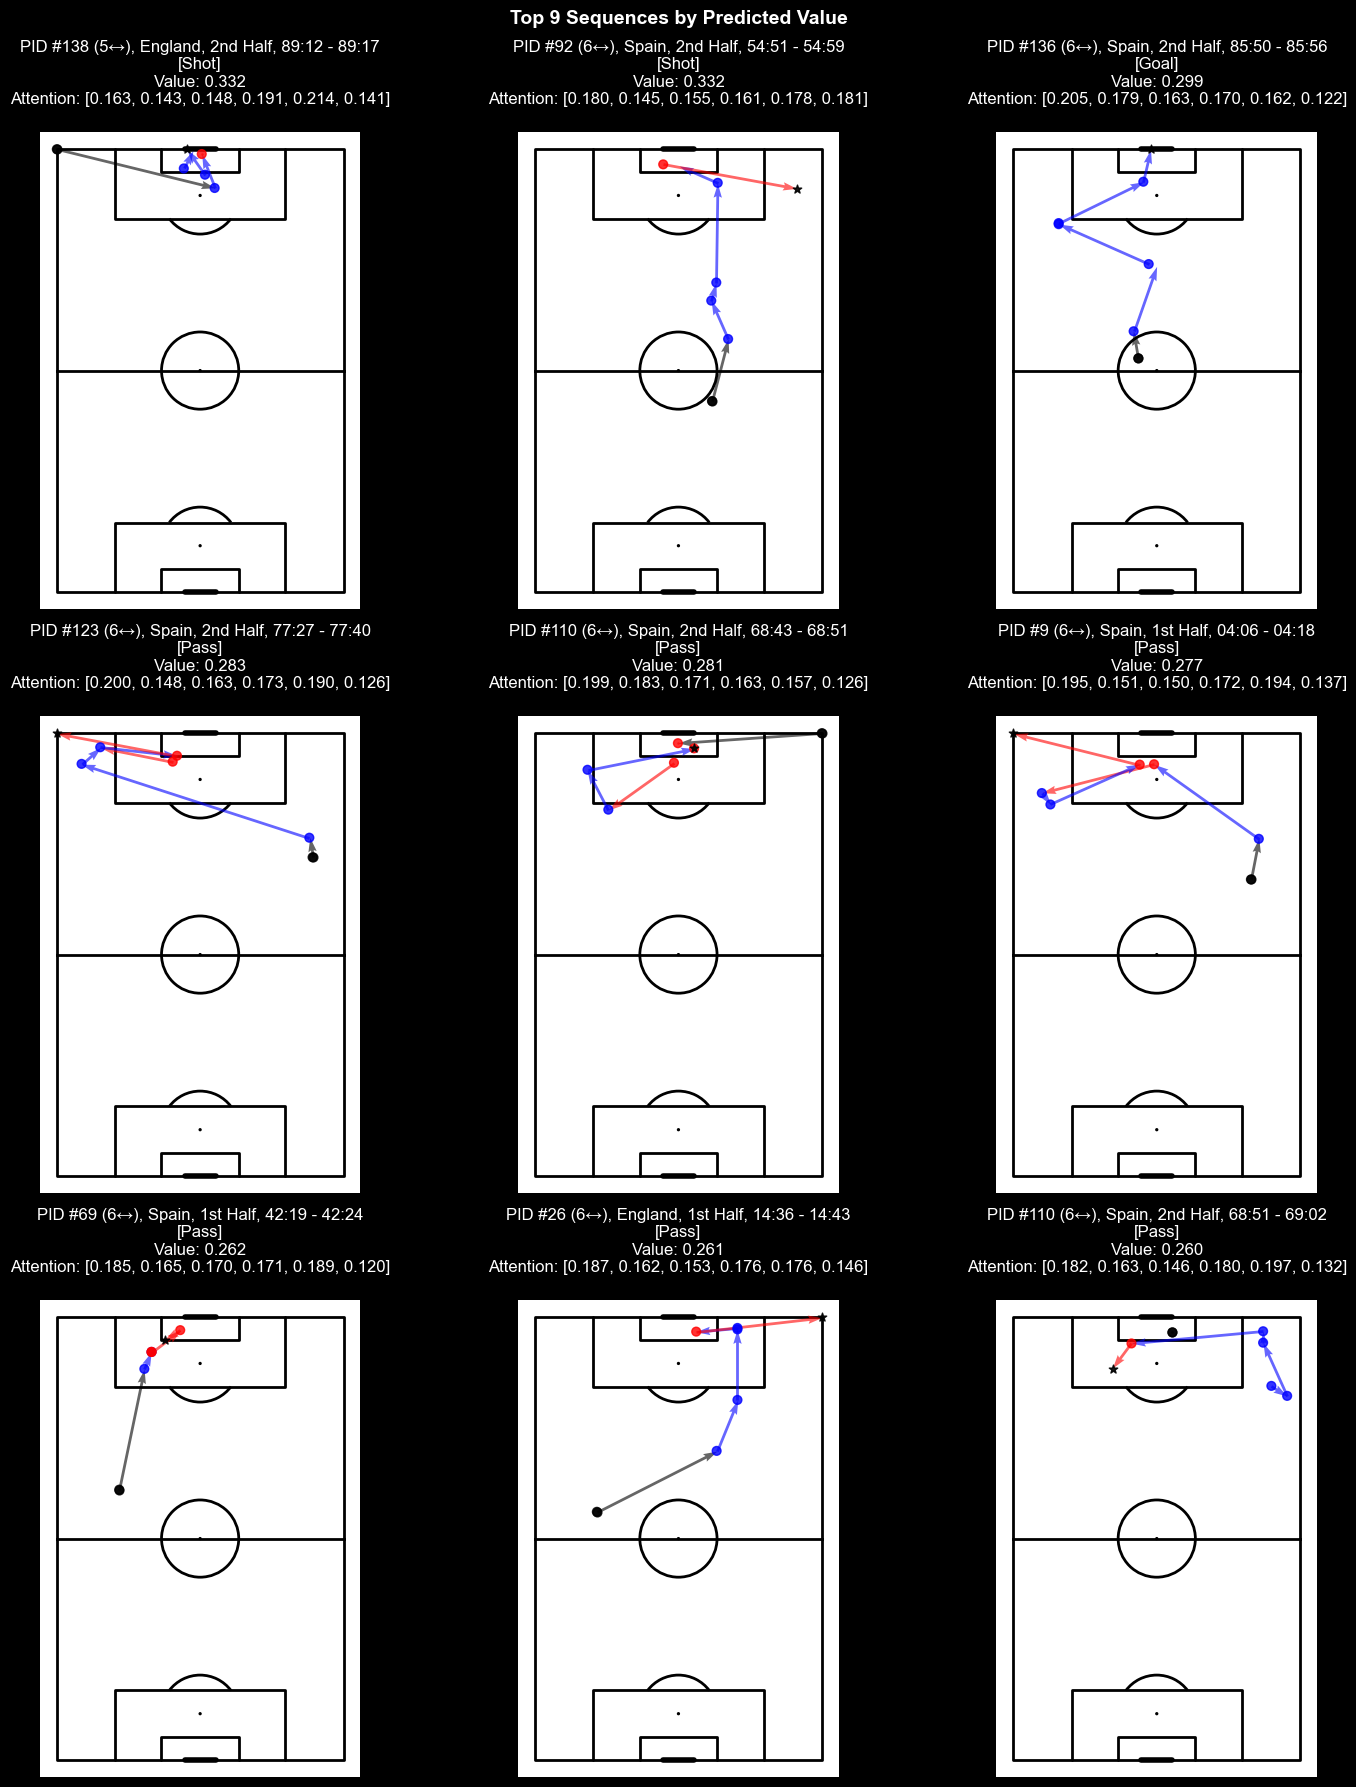

In [16]:
visualize_top_sequences(p, predicted_values, attention_weights, 9)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_final.png", dpi=300)
